# EVALUATION OUTPUT

Notebook final para la seccion global de resultados del TFM, pensado para una lectura **muy visual**, **ordenada** y **apta para memoria / tesis**.

## Estructura
1. **Retrieval directions dashboard**
   - Cross-modal `I->R`
   - Cross-modal `R->I`
   - Intramodal `R->R`
   - Intramodal `I->I`
2. **Majority-vote dashboard**
   - tabla por clases para AI4SKIN
   - tabla por clases para SICAP Gleason
   - resumen visual inferior para cada tabla
3. **Global synthesis dashboard**
   - bloque cross-modal orientado a clases
   - bloque cross-modal binario
   - bloque global
   - balance vs stability

## Principios
- No recalcula embeddings.
- `SAVE_FIGURES = False` por defecto.
- No usa `exact pair` en esta version.
- `same-dataset percentage` se muestra como **same-source retrieval** y no como rendimiento diagnostico.
- El tamano de burbuja en `balance vs stability` puede codificar coste de embedding si rellenas `IMAGE_EMBEDDING_SEC_PER_100`.

In [11]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.transforms import blended_transform_factory
from IPython.display import Markdown, display

from global_results_reporter import (
    MODEL_ORDER,
    K_VALUES,
    build_global_long_table,
    configure_matplotlib,
    discover_input_files,
    load_json,
    normalize_model_name,
)

SAVE_FIGURES = False
NOTEBOOK_NAME = "EVALUATION OUTPUT"

INPUT_DIR = Path.cwd()
OUTPUT_DIR = INPUT_DIR / "GLOBAL_RESULTS_REPORT_NOTEBOOK"
FIGURE_DIR = OUTPUT_DIR / "figures"

configure_matplotlib()
plt.rcParams.update(
    {
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "#434343",
        "axes.linewidth": 0.8,
        "savefig.dpi": 320,
    }
)

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COLORS = {
    "KEEP": "#4C72B0",
    "TITAN": "#C98533",
    "CONCH": "#4F8A62",
    "MUSK": "#7A5AB5",
    "Patho-CLIP": "#B95462",
    "PRISM": "#7C8796",
}

# Approximate image-embedding cost per 100 samples, derived from the
# practical runtimes reported during the experiments.
IMAGE_EMBEDDING_SEC_PER_100 = {
    "KEEP": 24.0,
    "TITAN": 24.0,
    "CONCH": 24.0,
    "MUSK": 144.0,
    "Patho-CLIP": 84.0,
    "PRISM": 1440.0,
}

SICAP_EMBED_ROOTS = {
    "KEEP": INPUT_DIR / "KEEP" / "SICAP" / "EMBEDDINGS",
    "TITAN": INPUT_DIR / "TITAN" / "SICAP" / "EMBEDDINGS",
    "CONCH": INPUT_DIR / "CONCH" / "SICAP" / "EMBEDDINGS",
    "MUSK": INPUT_DIR / "MUSK_V" / "SICAP" / "EMBEDDINGS",
    "Patho-CLIP": INPUT_DIR / "PATHO_CLIP" / "SICAP" / "EMBEDDINGS",
    "PRISM": INPUT_DIR / "PRISM" / "SICAP" / "EMBEDDINGS",
}

files = discover_input_files(INPUT_DIR)
ai4skin_metrics = load_json(files.required["ai4skin_metrics"])
sicap_metrics = load_json(files.required["sicap_metrics"])
domain_metrics = load_json(files.required["domain_metrics"])
majority_confusion = load_json(files.required["majority_voting_confusion"])

global_df = build_global_long_table(ai4skin_metrics, sicap_metrics, domain_metrics)
global_df = global_df[global_df["k"].isin(K_VALUES)].copy()

models = [model for model in MODEL_ORDER if model in set(global_df["model"])]

cross_task_specs = [
    ("AI4SKIN", "crossmodal_multiclass", "AI4SKIN multiclass"),
    ("AI4SKIN", "binary_crossmodal", "AI4SKIN binary"),
    ("SICAP", "binary_crossmodal", "SICAP binary"),
    ("SICAP", "gleason_crossmodal", "SICAP Gleason"),
    ("AI4SKIN vs ASSIST", "binary_crossmodal", "AI4SKIN vs ASSIST"),
]

rr_specs = [
    ("AI4SKIN", "intramodal_multiclass", "AI4SKIN R->R"),
    ("SICAP", "binary_intramodal", "SICAP binary R->R"),
    ("SICAP", "gleason_intramodal", "SICAP Gleason R->R"),
]

ii_specs = [
    ("AI4SKIN", "intramodal_multiclass", "AI4SKIN I->I"),
    ("SICAP", "binary_intramodal", "SICAP binary I->I"),
    ("SICAP", "gleason_intramodal", "SICAP Gleason I->I"),
]

binary_specs = [
    ("AI4SKIN", "binary_crossmodal", "AI4SKIN binary"),
    ("SICAP", "binary_crossmodal", "SICAP binary"),
    ("AI4SKIN vs ASSIST", "binary_crossmodal", "AI4SKIN vs ASSIST"),
]

AI4SKIN_CLASS_SHORT = {
    "Leiomioma (angio/pilo)": "Leiomioma",
    "Leiomiosarcoma": "Leiomiosarcoma",
    "Dermatofibroma": "Dermatofibroma",
    "Dermatofibrosarcoma protuberans": "DFSP",
    "Melanoma": "Melanoma",
    "Fibroxantoma atipico / Sarcoma pleomorfico dermico": "AFX / PDS",
    "Fibroxantoma atípico / Sarcoma pleomórfico dérmico": "AFX / PDS",
    "Carcinoma escamoso (fusocelular/sarcomatoide)": "Spindle cSCC",
}

SICAP_CLASS_ORDER = [
    "6 (3+3)",
    "7 (3+4)",
    "7 (4+3)",
    "8 (4+4)",
    "9 (4+5)",
    "9 (5+4)",
]


def maybe_save(fig, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")


def thesis_cmap():
    cmap = LinearSegmentedColormap.from_list(
        "thesis_blue",
        ["#F8FBFD", "#DCE8F1", "#A9C4D9", "#6C97BD", "#2F5D86"],
    )
    cmap.set_bad(color="#EFEFEF")
    return cmap


def wrap_label(text: str, width: int = 18) -> str:
    return "\n".join(textwrap.wrap(str(text), width=width, break_long_words=False))


def nanmean_safe(values) -> float:
    arr = np.asarray(values, dtype=float)
    return float(np.nanmean(arr)) if np.isfinite(arr).any() else np.nan


def nanstd_safe(values) -> float:
    arr = np.asarray(values, dtype=float)
    return float(np.nanstd(arr, ddof=0)) if np.isfinite(arr).any() else np.nan


def l2_normalize_rows(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return matrix / norms


def majority_vote_pred(topk_classes: np.ndarray, topk_sims: np.ndarray) -> str:
    classes = np.asarray(topk_classes)
    sims = np.asarray(topk_sims, dtype=float)
    uniq, counts = np.unique(classes, return_counts=True)
    max_count = counts.max()
    candidates = uniq[counts == max_count]
    if len(candidates) == 1:
        return str(candidates[0])

    best_label = None
    best_sim_sum = -np.inf
    for candidate in candidates:
        sim_sum = float(np.sum(sims[classes == candidate]))
        if sim_sum > best_sim_sum:
            best_label = candidate
            best_sim_sum = sim_sum
    if best_label is None:
        best_label = classes[0]
    return str(best_label)


def values_for(dataset, task, direction, model, metric_type="recall"):
    mask = (
        (global_df["dataset"] == dataset)
        & (global_df["task"] == task)
        & (global_df["direction"] == direction)
        & (global_df["metric_type"] == metric_type)
        & (global_df["model"] == model)
    )
    return global_df.loc[mask, "value"].astype(float).to_numpy()


def mean_over_k(dataset, task, direction, model, metric_type="recall") -> float:
    return nanmean_safe(values_for(dataset, task, direction, model, metric_type=metric_type))


def mean_over_crossmodal(dataset, task, model) -> float:
    values = []
    for direction in ["report_to_image", "image_to_report"]:
        values.extend(values_for(dataset, task, direction, model, metric_type="recall"))
    return nanmean_safe(values)


def build_direction_summary(task_specs, direction):
    rows = []
    for model in models:
        task_values = []
        for dataset, task, _ in task_specs:
            task_values.append(mean_over_k(dataset, task, direction, model))
        task_values = np.array(task_values, dtype=float)
        rows.append(
            {
                "model": model,
                "mean": nanmean_safe(task_values),
                "std": nanstd_safe(task_values),
                "task_values": task_values,
            }
        )
    return pd.DataFrame(rows)


def build_block_summary(task_specs):
    rows = []
    for model in models:
        task_values = [mean_over_crossmodal(dataset, task, model) for dataset, task, _ in task_specs]
        rows.append(
            {
                "model": model,
                "mean": nanmean_safe(task_values),
                "std": nanstd_safe(task_values),
                "task_values": np.asarray(task_values, dtype=float),
            }
        )
    return pd.DataFrame(rows)


def lookup_key(mapping, key):
    for candidate in [key, str(key)]:
        if candidate in mapping:
            return mapping[candidate]
    return None


def raw_model_name(block, canonical_model):
    for raw_name in block:
        if normalize_model_name(raw_name) == canonical_model:
            return raw_name
    return None


def ai4skin_class_metadata():
    csv_path = INPUT_DIR / "AI4SKIN_labels.csv"
    if not csv_path.exists():
        return [str(i) for i in range(7)], [f"Class {i}" for i in range(7)]
    df = pd.read_csv(csv_path)
    uniq = (
        df[["class_id", "class_name"]]
        .drop_duplicates()
        .sort_values("class_id")
        .reset_index(drop=True)
    )
    class_ids = [str(int(x)) for x in uniq["class_id"].tolist()]
    class_labels = []
    for name in uniq["class_name"].tolist():
        class_labels.append(AI4SKIN_CLASS_SHORT.get(name, name))
    return class_ids, class_labels


def sicap_metadata():
    meta_path = INPUT_DIR / "SICAP_Evaluation" / "metadata" / "sicap_metadata_eval.csv"
    meta = pd.read_csv(meta_path, dtype=str).fillna("")
    for col in ["ID grupo", "Fragmento final", "gleason_label_eval"]:
        meta[col] = meta[col].astype(str).str.strip()
    meta = meta[meta["gleason_label_eval"].isin(SICAP_CLASS_ORDER)].copy()
    return meta.reset_index(drop=True)


def load_sicap_embeddings_for_model(model):
    root = SICAP_EMBED_ROOTS.get(model)
    if root is None or not root.exists():
        return None

    text_dir = root / "text_final"
    image_dir = root / "image_final"
    if not text_dir.exists() or not image_dir.exists():
        return None

    text_map = {}
    for path in text_dir.glob("*.npy"):
        group_id = path.stem.split("_grouptext")[0]
        text_map[group_id] = np.load(path)

    image_map = {}
    for path in image_dir.glob("*.npy"):
        image_key = path.stem[:-4] if path.stem.endswith("_img") else path.stem
        image_map[image_key] = np.load(path)

    meta = sicap_metadata()
    ids, labels, txt_rows, img_rows = [], [], [], []
    for _, row in meta.iterrows():
        group_id = row["ID grupo"]
        fragment_id = row["Fragmento final"]
        label = row["gleason_label_eval"]
        if group_id in text_map and fragment_id in image_map:
            ids.append(group_id)
            labels.append(label)
            txt_rows.append(np.asarray(text_map[group_id], dtype=float).ravel())
            img_rows.append(np.asarray(image_map[fragment_id], dtype=float).ravel())

    if not txt_rows or not img_rows:
        return None

    x_txt = l2_normalize_rows(np.stack(txt_rows, axis=0))
    x_img = l2_normalize_rows(np.stack(img_rows, axis=0))
    return {
        "ids": ids,
        "labels": np.asarray(labels, dtype=str),
        "x_txt": x_txt,
        "x_img": x_img,
    }


def build_ai4skin_majority_matrix():
    class_ids, class_labels = ai4skin_class_metadata()
    root = majority_confusion.get("multiclass_crossmodal", {})
    rows = []
    for class_id, class_label in zip(class_ids, class_labels):
        row = {"class_label": class_label}
        for model in models:
            raw_model = raw_model_name(root, model)
            values = []
            if raw_model is not None:
                dataset_block = root.get(raw_model, {}).get("AI4SKIN", {})
                for direction in ["report_to_image", "image_to_report"]:
                    direction_block = dataset_block.get(direction, {})
                    for k in K_VALUES:
                        k_block = lookup_key(direction_block, k) or {}
                        row_block = lookup_key(k_block, class_id) or {}
                        value = lookup_key(row_block, class_id)
                        if value is not None:
                            values.append(float(value))
            row[model] = nanmean_safe(values)
        rows.append(row)
    return pd.DataFrame(rows)


def build_sicap_majority_matrix():
    rows = []
    for model in models:
        bundle = load_sicap_embeddings_for_model(model)
        per_model = {class_label: [] for class_label in SICAP_CLASS_ORDER}
        if bundle is not None:
            labels = bundle["labels"]
            sims_by_direction = {
                "report_to_image": bundle["x_txt"] @ bundle["x_img"].T,
                "image_to_report": bundle["x_img"] @ bundle["x_txt"].T,
            }
            for direction, sim in sims_by_direction.items():
                for k in K_VALUES:
                    k_int = int(k)
                    for idx, true_label in enumerate(labels):
                        order = np.argsort(-sim[idx])[:k_int]
                        pred_label = majority_vote_pred(labels[order], sim[idx, order])
                        per_model[str(true_label)].append(float(pred_label == str(true_label)))

        rows.append({"model": model, **{label: nanmean_safe(per_model[label]) for label in SICAP_CLASS_ORDER}})

    matrix_df = pd.DataFrame(rows).set_index("model").T.reset_index().rename(columns={"index": "class_label"})
    return matrix_df


def append_mean_summary_row(class_df):
    summary = {"class_label": "Mean across classes"}
    for model in models:
        summary[model] = nanmean_safe(class_df[model].astype(float).to_numpy())
    return pd.concat([class_df, pd.DataFrame([summary])], ignore_index=True)


def block_summary_from_matrix(class_df, exclude_label="Mean across classes"):
    rows = []
    base_df = class_df[class_df["class_label"] != exclude_label].copy()
    for model in models:
        values = base_df[model].astype(float).to_numpy()
        rows.append(
            {
                "model": model,
                "mean": nanmean_safe(values),
                "std": nanstd_safe(values),
                "task_values": values,
            }
        )
    return pd.DataFrame(rows)


def summary_map(summary_df):
    return summary_df.set_index("model")["mean"].to_dict()


def add_best_boxes(ax, matrix, mode="max", skip_cols=None):
    skip_cols = set(skip_cols or [])
    for col in range(matrix.shape[1]):
        if col in skip_cols:
            continue
        values = matrix[:, col]
        finite = np.isfinite(values)
        if not finite.any():
            continue
        target = np.nanmax(values) if mode == "max" else np.nanmin(values)
        winners = np.where(np.isclose(values, target, equal_nan=False))[0]
        for row in winners:
            ax.add_patch(
                Rectangle(
                    (col - 0.5, row - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="#B48A1E",
                    linewidth=2.6,
                )
            )
            ax.add_patch(
                Rectangle(
                    (col - 0.46, row - 0.46),
                    0.92,
                    0.92,
                    fill=False,
                    edgecolor="#111111",
                    linewidth=1.2,
                )
            )


def draw_block_headers(ax, blocks):
    start = 0
    total = sum(width for _, width, _ in blocks)
    for label, width, color in blocks:
        x0 = start / total
        rect = Rectangle(
            (x0, 1.035),
            width / total,
            0.08,
            transform=ax.transAxes,
            clip_on=False,
            facecolor=color,
            edgecolor="#D0D7DE",
            linewidth=0.8,
        )
        ax.add_patch(rect)
        ax.text(
            x0 + (width / total) / 2.0,
            1.075,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=12.5,
            fontweight="bold",
            color="#334155",
        )
        start += width


def annotate_heatmap(ax, matrix, special_columns=None):
    special_columns = special_columns or {}
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = matrix[row, col]
            if np.isnan(value):
                text = "--"
                color = "#666666"
            else:
                fmt = special_columns.get(col, "{:.3f}")
                text = fmt.format(value)
                color = "white" if value >= 0.63 else "#1A1A1A"
            ax.text(
                col,
                row,
                text,
                ha="center",
                va="center",
                fontsize=8.7,
                fontweight="bold",
                color=color,
            )


def plot_direction_panel(ax, summary_df, title, highlight_note):
    ordered = summary_df.sort_values("mean", ascending=False).reset_index(drop=True)
    y_positions = np.arange(len(ordered))
    best_model = ordered.loc[0, "model"]
    trans = blended_transform_factory(ax.transAxes, ax.transData)

    for y, (_, row) in enumerate(ordered.iterrows()):
        is_best = row["model"] == best_model
        if is_best:
            ax.axhspan(y - 0.46, y + 0.46, color="#F6F1DE", zorder=0)

        ax.barh(
            y,
            row["mean"],
            color=MODEL_COLORS[row["model"]],
            alpha=0.90,
            height=0.60,
            edgecolor="#202020" if is_best else "none",
            linewidth=1.3 if is_best else 0.0,
            zorder=1,
        )
        ax.errorbar(
            row["mean"],
            y,
            xerr=row["std"],
            fmt="none",
            ecolor="#1E1E1E",
            elinewidth=1.2,
            capsize=3.2,
            zorder=4,
        )

        task_values = np.asarray(row["task_values"], dtype=float)
        task_values = task_values[np.isfinite(task_values)]
        if len(task_values):
            ax.scatter(
                task_values,
                np.full(len(task_values), y),
                s=34,
                color=MODEL_COLORS[row["model"]],
                alpha=0.30,
                edgecolor="white",
                linewidth=0.45,
                zorder=3,
            )

        label = "--" if np.isnan(row["mean"]) else f"{row['mean']:.3f} +/- {row['std']:.3f}"
        ax.text(
            1.01,
            y,
            label,
            transform=trans,
            ha="left",
            va="center",
            fontsize=10.4,
            color="#303030",
            fontweight="bold",
        )

    ax.set_title(title, loc="left", y=1.09, pad=0, fontweight="bold")
    ax.text(
        0.0,
        1.025,
        highlight_note,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9.1,
        color="#5B6673",
    )
    ax.set_xlim(0.0, 1.02)
    ax.set_xticks(np.arange(0.0, 1.01, 0.2))
    ax.set_xlabel("Mean Recall@K")
    ax.set_yticks(y_positions)
    ax.set_yticklabels(ordered["model"].tolist())
    ax.grid(True, axis="x", color="#D9DFE6", linewidth=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.invert_yaxis()


def draw_class_heatmap(ax, class_df, title, subtitle):
    matrix = class_df[models].to_numpy(dtype=float)
    im = ax.imshow(np.ma.masked_invalid(matrix), aspect="auto", cmap=thesis_cmap(), vmin=0.0, vmax=1.0)
    ax.set_title(title, loc="left", y=1.08, pad=0, fontweight="bold")
    ax.text(
        0.0,
        1.025,
        subtitle,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=9.0,
        color="#5B6673",
    )
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models)
    ax.set_yticks(np.arange(len(class_df)))
    ax.set_yticklabels([wrap_label(label, 18) for label in class_df["class_label"].tolist()])
    ax.set_xticks(np.arange(-0.5, len(models), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(class_df), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    if len(class_df):
        ax.axhline(len(class_df) - 1.5, color="#222222", linewidth=2.0)
    add_best_boxes(ax, matrix, mode="max")
    annotate_heatmap(ax, matrix)
    yticklabels = ax.get_yticklabels()
    if yticklabels:
        yticklabels[-1].set_fontweight("bold")
    return im


def plot_rank_summary(ax, summary_df, title, x_label):
    ordered = summary_df.sort_values("mean", ascending=False).reset_index(drop=True)
    y_positions = np.arange(len(ordered))
    best_model = ordered.loc[0, "model"]
    box_data = []
    for _, row in ordered.iterrows():
        values = np.asarray(row["task_values"], dtype=float)
        values = values[np.isfinite(values)]
        box_data.append(values if len(values) else np.array([np.nan]))

    bp = ax.boxplot(
        box_data,
        vert=False,
        positions=y_positions,
        widths=0.56,
        patch_artist=True,
        showfliers=False,
        whis=(0, 100),
        medianprops={"color": "#111111", "linewidth": 1.3},
        whiskerprops={"color": "#353535", "linewidth": 1.1},
        capprops={"color": "#353535", "linewidth": 1.1},
    )
    for patch, (_, row) in zip(bp["boxes"], ordered.iterrows()):
        patch.set_facecolor(MODEL_COLORS[row["model"]])
        patch.set_alpha(0.65)
        patch.set_edgecolor("#202020")
        patch.set_linewidth(1.0)

    for y, (_, row) in enumerate(ordered.iterrows()):
        is_best = row["model"] == best_model
        if is_best:
            ax.axhspan(y - 0.46, y + 0.46, color="#F6F1DE", zorder=0)

        values = np.asarray(row["task_values"], dtype=float)
        values = values[np.isfinite(values)]
        if len(values):
            jitter = np.linspace(-0.10, 0.10, len(values))
            ax.scatter(
                values,
                np.full(len(values), y) + jitter,
                s=28,
                color=MODEL_COLORS[row["model"]],
                alpha=0.28,
                edgecolor="white",
                linewidth=0.35,
                zorder=3,
            )

        ax.errorbar(
            row["mean"],
            y,
            xerr=row["std"],
            fmt="o",
            markersize=6.8,
            markerfacecolor="#111111",
            markeredgecolor="white",
            ecolor="#111111",
            elinewidth=1.2,
            capsize=3.2,
            zorder=4,
        )
        ax.text(
            1.02,
            y,
            f"{row['mean']:.3f} +/- {row['std']:.3f}",
            ha="left",
            va="center",
            fontsize=10.2,
            color="#222222",
            fontweight="bold",
        )

    ax.set_title(title, pad=10, fontweight="bold")
    ax.set_xlim(0.0, 1.14)
    ax.set_xlabel(x_label)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(ordered["model"].tolist())
    ax.grid(True, axis="x", color="#D9DFE6", linewidth=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.invert_yaxis()


def scale_bubble_sizes(cost_mapping, index_models):
    raw = np.array([cost_mapping.get(model, np.nan) for model in index_models], dtype=float)
    finite = np.isfinite(raw)
    if finite.any():
        scaled_raw = np.log10(raw[finite])
        vmin = float(np.nanmin(scaled_raw))
        vmax = float(np.nanmax(scaled_raw))
        if np.isclose(vmin, vmax):
            return np.full(len(index_models), 620.0)
        scaled = np.full(len(index_models), 520.0)
        scaled[finite] = 340.0 + (np.log10(raw[finite]) - vmin) / (vmax - vmin) * 620.0
        scaled[~finite] = 520.0
        return scaled
    return np.full(len(index_models), 620.0)


i2r_summary = build_direction_summary(cross_task_specs, "image_to_report")
r2i_summary = build_direction_summary(cross_task_specs, "report_to_image")
rr_summary = build_direction_summary(rr_specs, "report_to_report")
ii_summary = build_direction_summary(ii_specs, "image_to_image")

ai4skin_majority_df = append_mean_summary_row(build_ai4skin_majority_matrix())
sicap_majority_df = append_mean_summary_row(build_sicap_majority_matrix())
ai4skin_majority_summary = block_summary_from_matrix(ai4skin_majority_df)
sicap_majority_summary = block_summary_from_matrix(sicap_majority_df)
ai4skin_majority_mean_map = summary_map(ai4skin_majority_summary)
sicap_majority_mean_map = summary_map(sicap_majority_summary)

summary_rows = []
for model in models:
    fine_values = [
        mean_over_crossmodal("AI4SKIN", "crossmodal_multiclass", model),
        ai4skin_majority_mean_map.get(model, np.nan),
        mean_over_crossmodal("SICAP", "gleason_crossmodal", model),
        sicap_majority_mean_map.get(model, np.nan),
    ]
    binary_values = [mean_over_crossmodal(ds, task, model) for ds, task, _ in binary_specs]
    same_dataset_values = []
    for direction in ["report_to_image", "image_to_report"]:
        same_dataset_values.extend(
            values_for(
                "AI4SKIN vs ASSIST",
                "binary_crossmodal",
                direction,
                model,
                metric_type="same_dataset_pct",
            )
        )
    benchmark_values = np.array(fine_values + binary_values, dtype=float)
    overall_mean = nanmean_safe(benchmark_values)
    overall_std = nanstd_safe(benchmark_values)
    summary_rows.append(
        {
            "model": model,
            "AI4SKIN multiclass": fine_values[0],
            "AI4SKIN majority": fine_values[1],
            "SICAP Gleason": fine_values[2],
            "SICAP majority": fine_values[3],
            "Class-aware mean": nanmean_safe(fine_values),
            "AI4SKIN binary": binary_values[0],
            "SICAP binary": binary_values[1],
            "AI4SKIN vs ASSIST": binary_values[2],
            "Binary mean": nanmean_safe(binary_values),
            "Same-source retrieval": nanmean_safe(same_dataset_values),
            "Overall mean": overall_mean,
            "Overall std": overall_std,
            "Completeness": overall_mean - overall_std if np.isfinite(overall_mean) and np.isfinite(overall_std) else np.nan,
            "_classaware_task_values": np.asarray(fine_values, dtype=float),
            "_binary_task_values": np.asarray(binary_values, dtype=float),
        }
    )

summary_df = pd.DataFrame(summary_rows)
fine_summary = pd.DataFrame(
    [
        {
            "model": row["model"],
            "mean": row["Class-aware mean"],
            "std": nanstd_safe(row["_classaware_task_values"]),
            "task_values": row["_classaware_task_values"],
        }
        for _, row in summary_df.iterrows()
    ]
)
binary_summary = pd.DataFrame(
    [
        {
            "model": row["model"],
            "mean": row["Binary mean"],
            "std": nanstd_safe(row["_binary_task_values"]),
            "task_values": row["_binary_task_values"],
        }
        for _, row in summary_df.iterrows()
    ]
)
most_complete_model = (
    summary_df.sort_values("Completeness", ascending=False).iloc[0]["model"]
    if not summary_df.empty
    else None
)

print(f"{NOTEBOOK_NAME} ready.")
print("Datasets:", sorted(global_df["dataset"].unique()))
print("Models:", models)
if np.isfinite(np.array(list(IMAGE_EMBEDDING_SEC_PER_100.values()), dtype=float)).any():
    print("Bubble sizes will encode image-embedding cost.")
else:
    print("Bubble sizes use equal-size fallback. Fill IMAGE_EMBEDDING_SEC_PER_100 to encode cost.")

EVALUATION OUTPUT ready.
Datasets: ['AI4SKIN', 'AI4SKIN vs ASSIST', 'SICAP']
Models: ['KEEP', 'TITAN', 'CONCH', 'MUSK', 'Patho-CLIP', 'PRISM']
Bubble sizes will encode image-embedding cost.


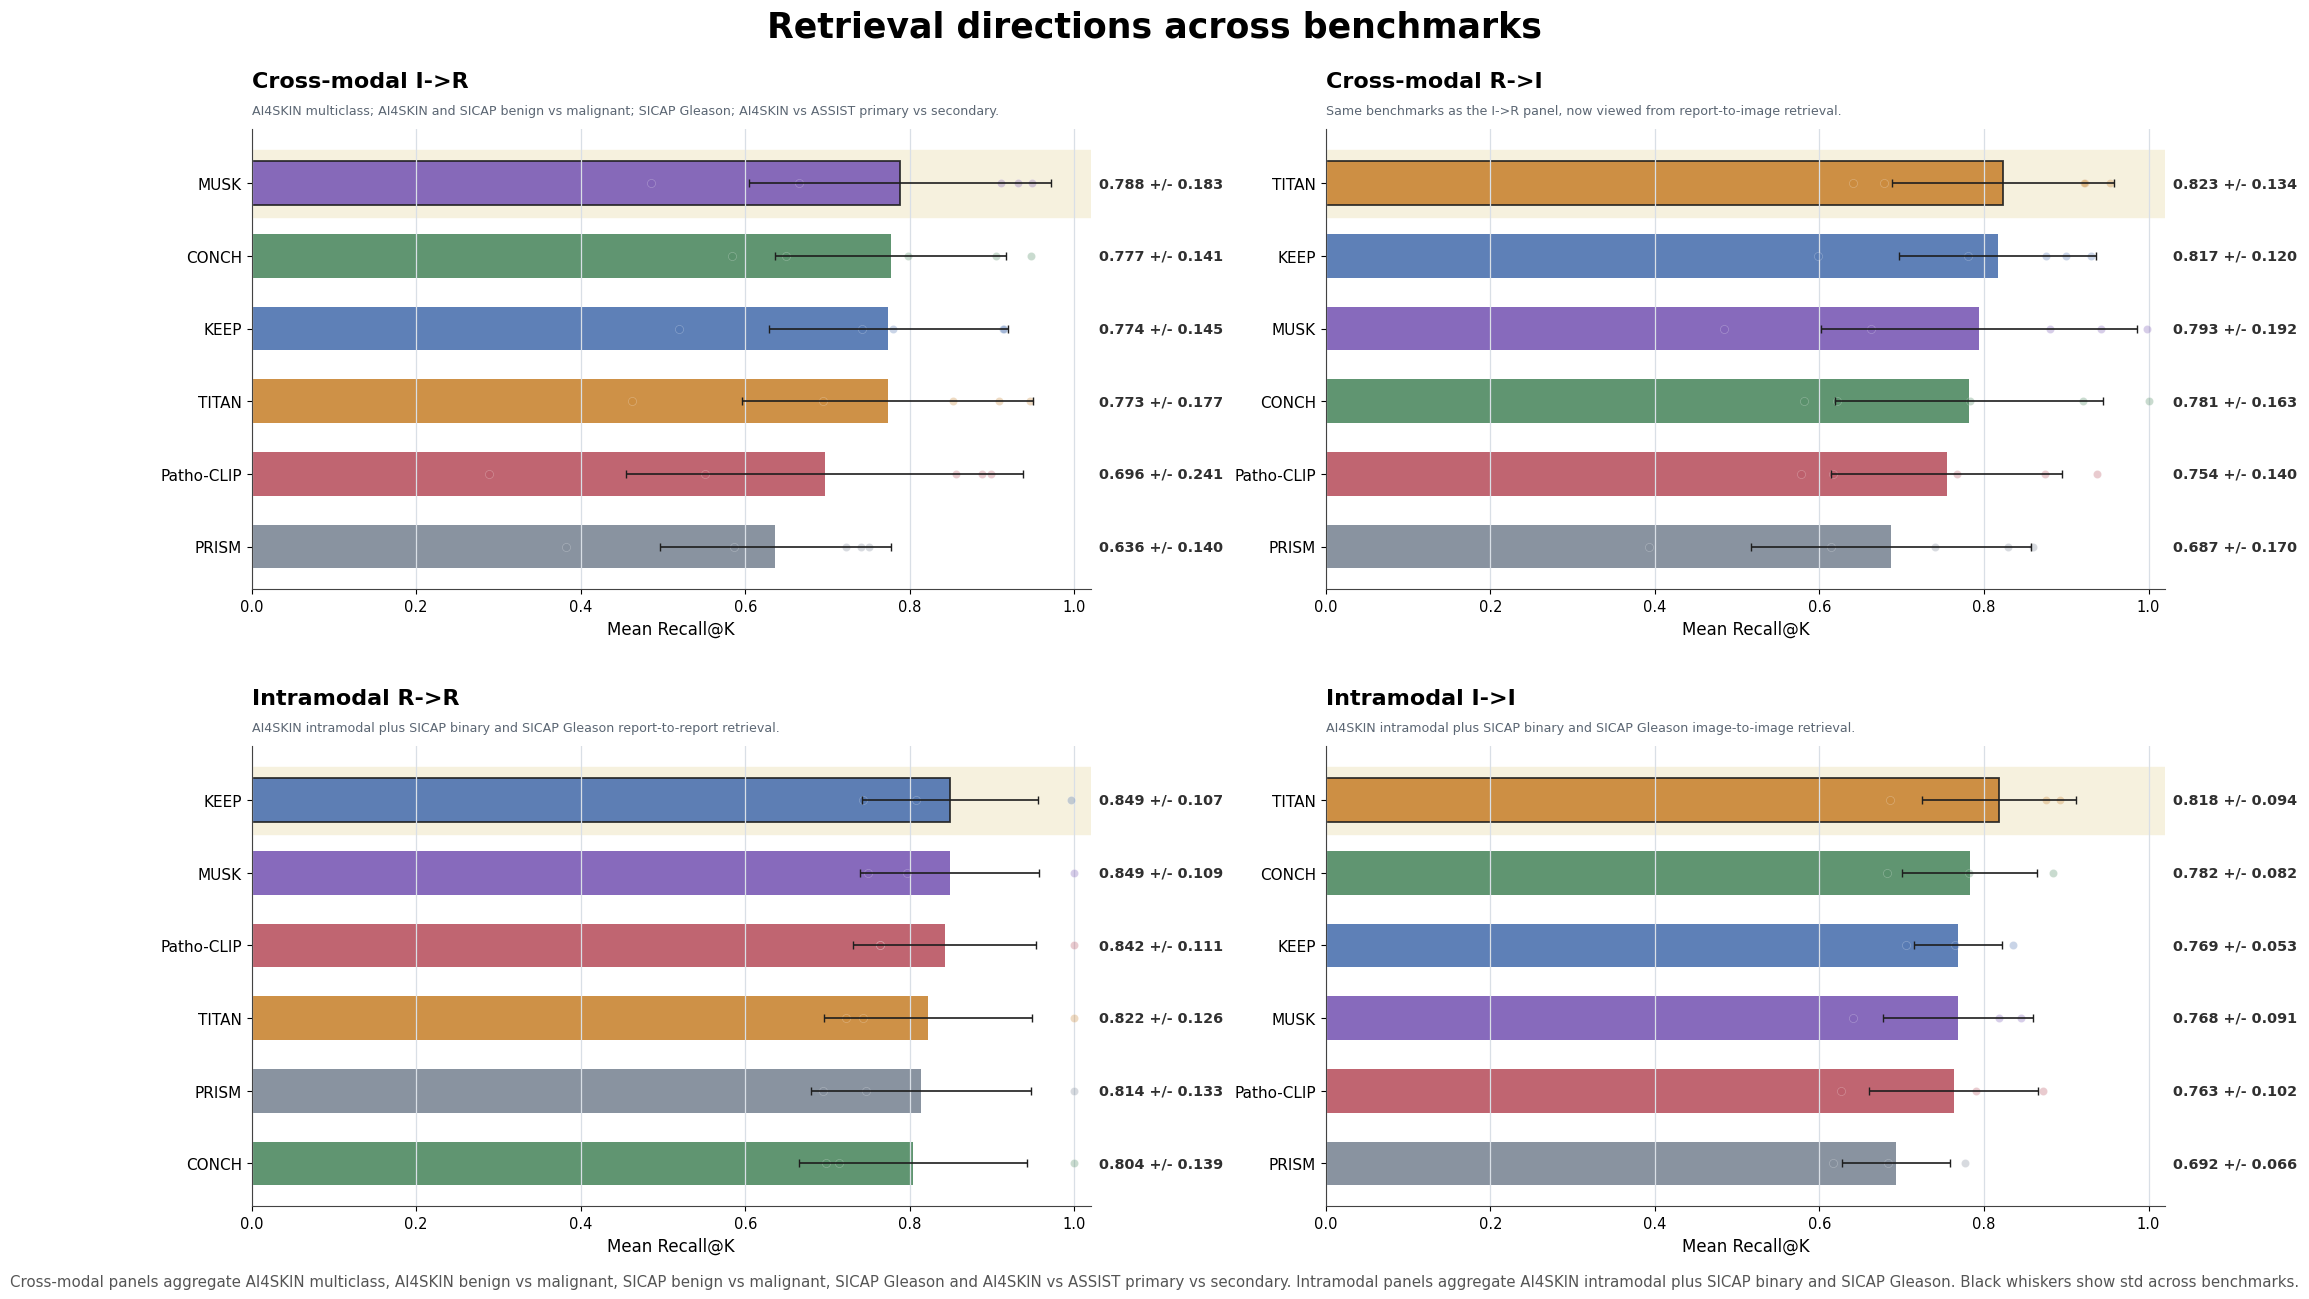

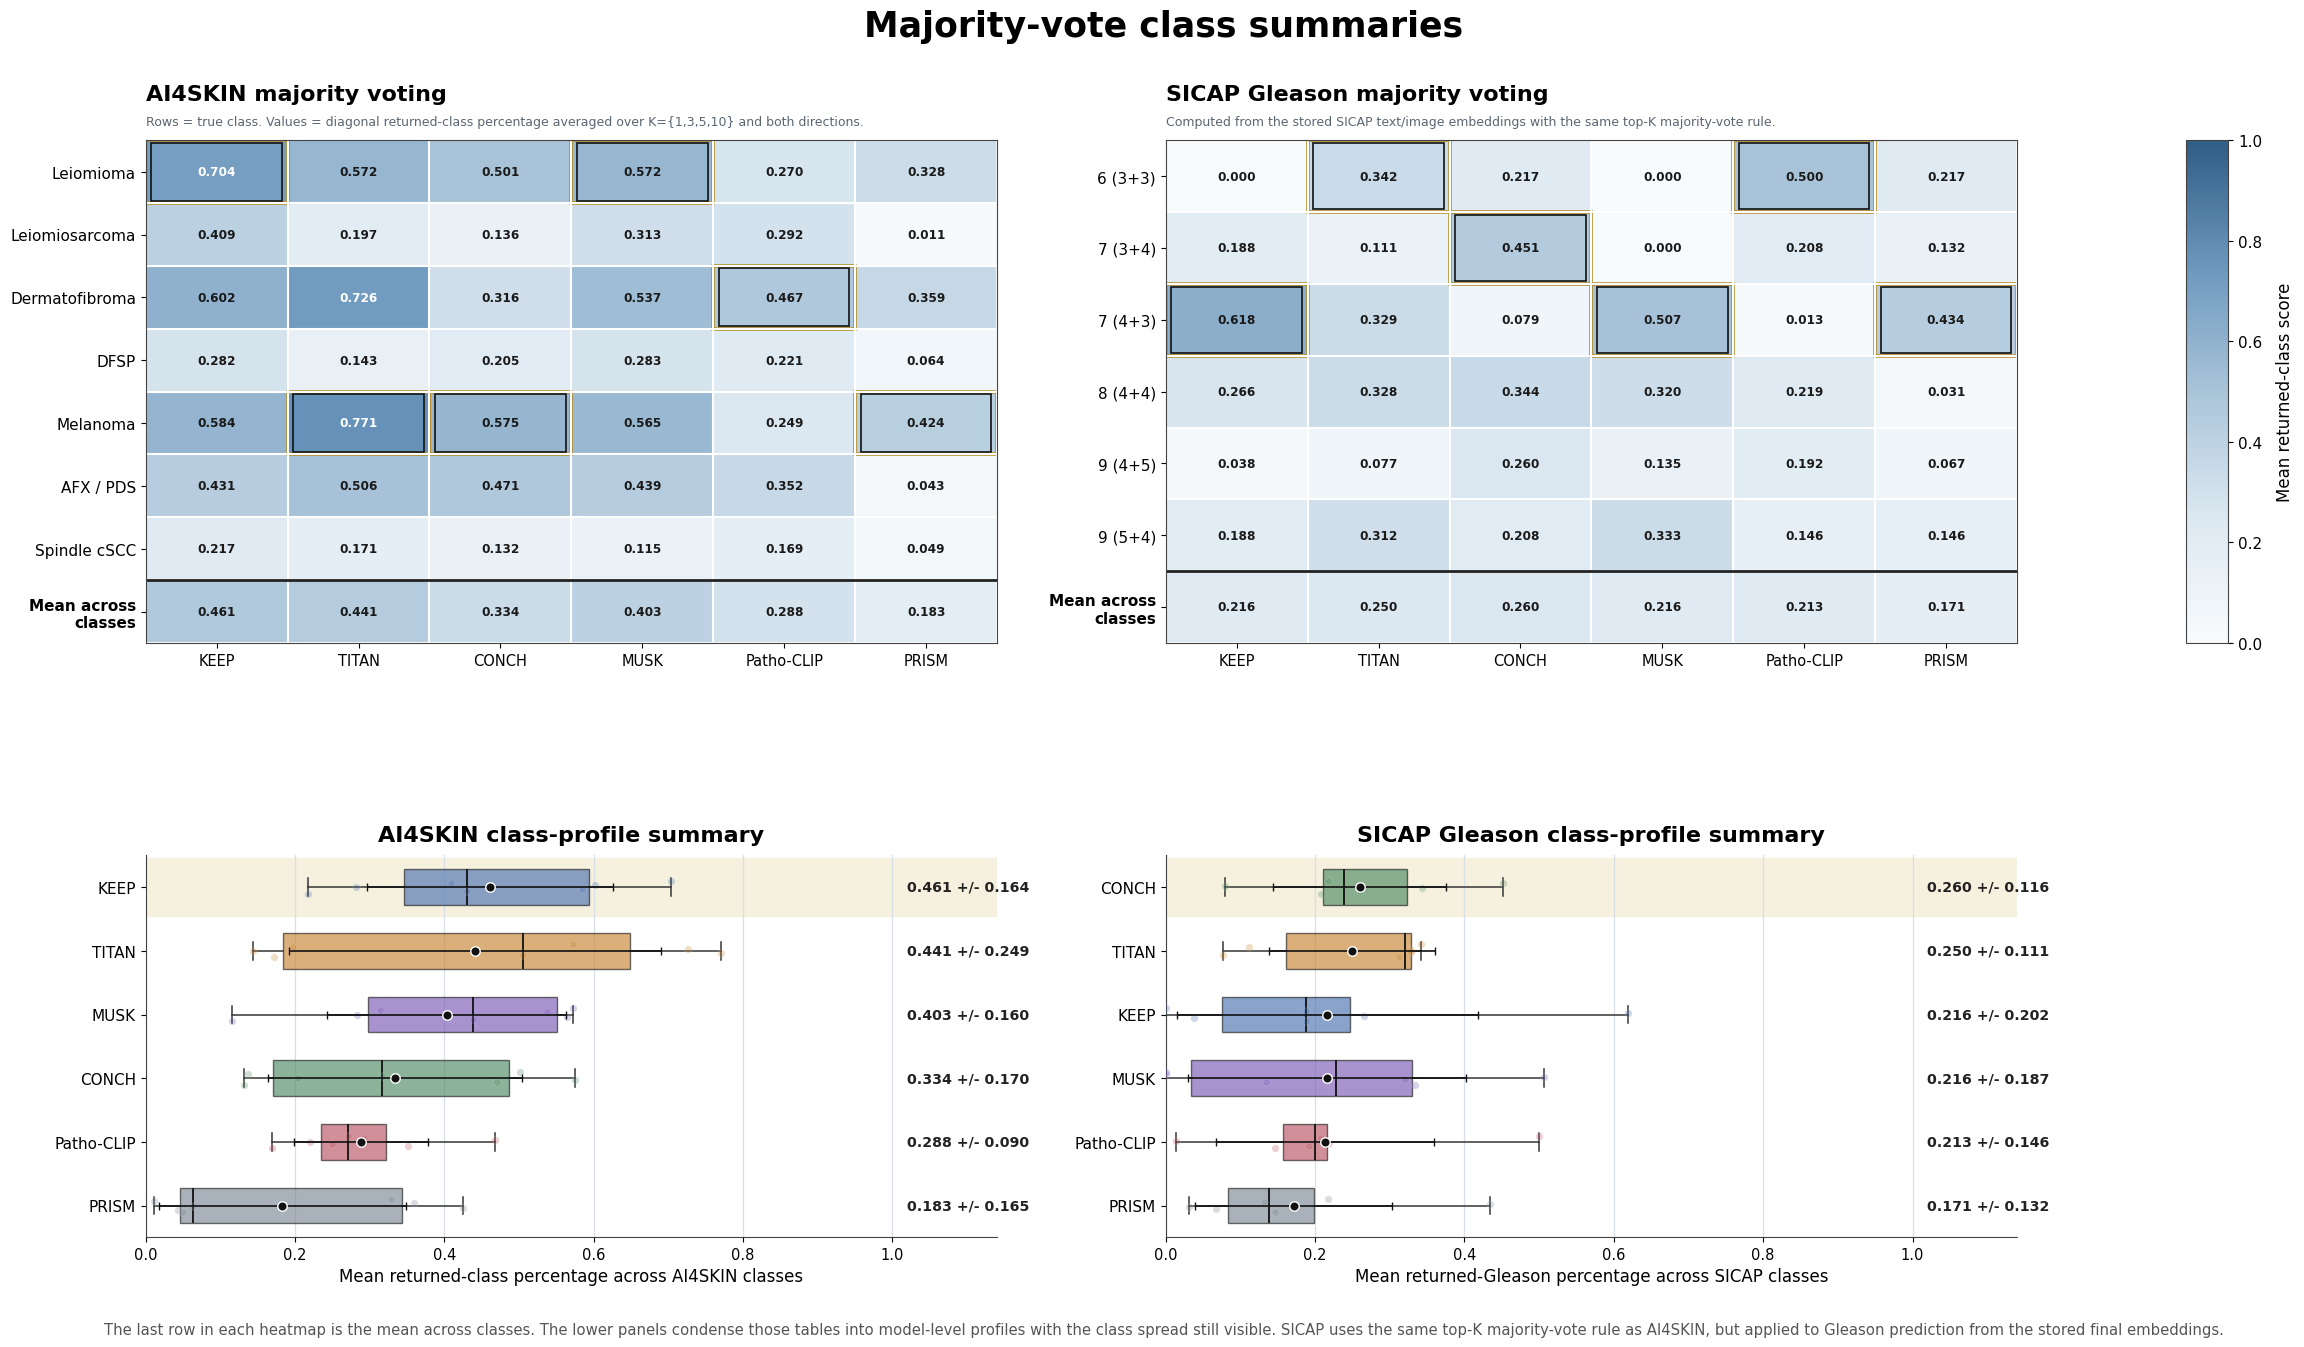

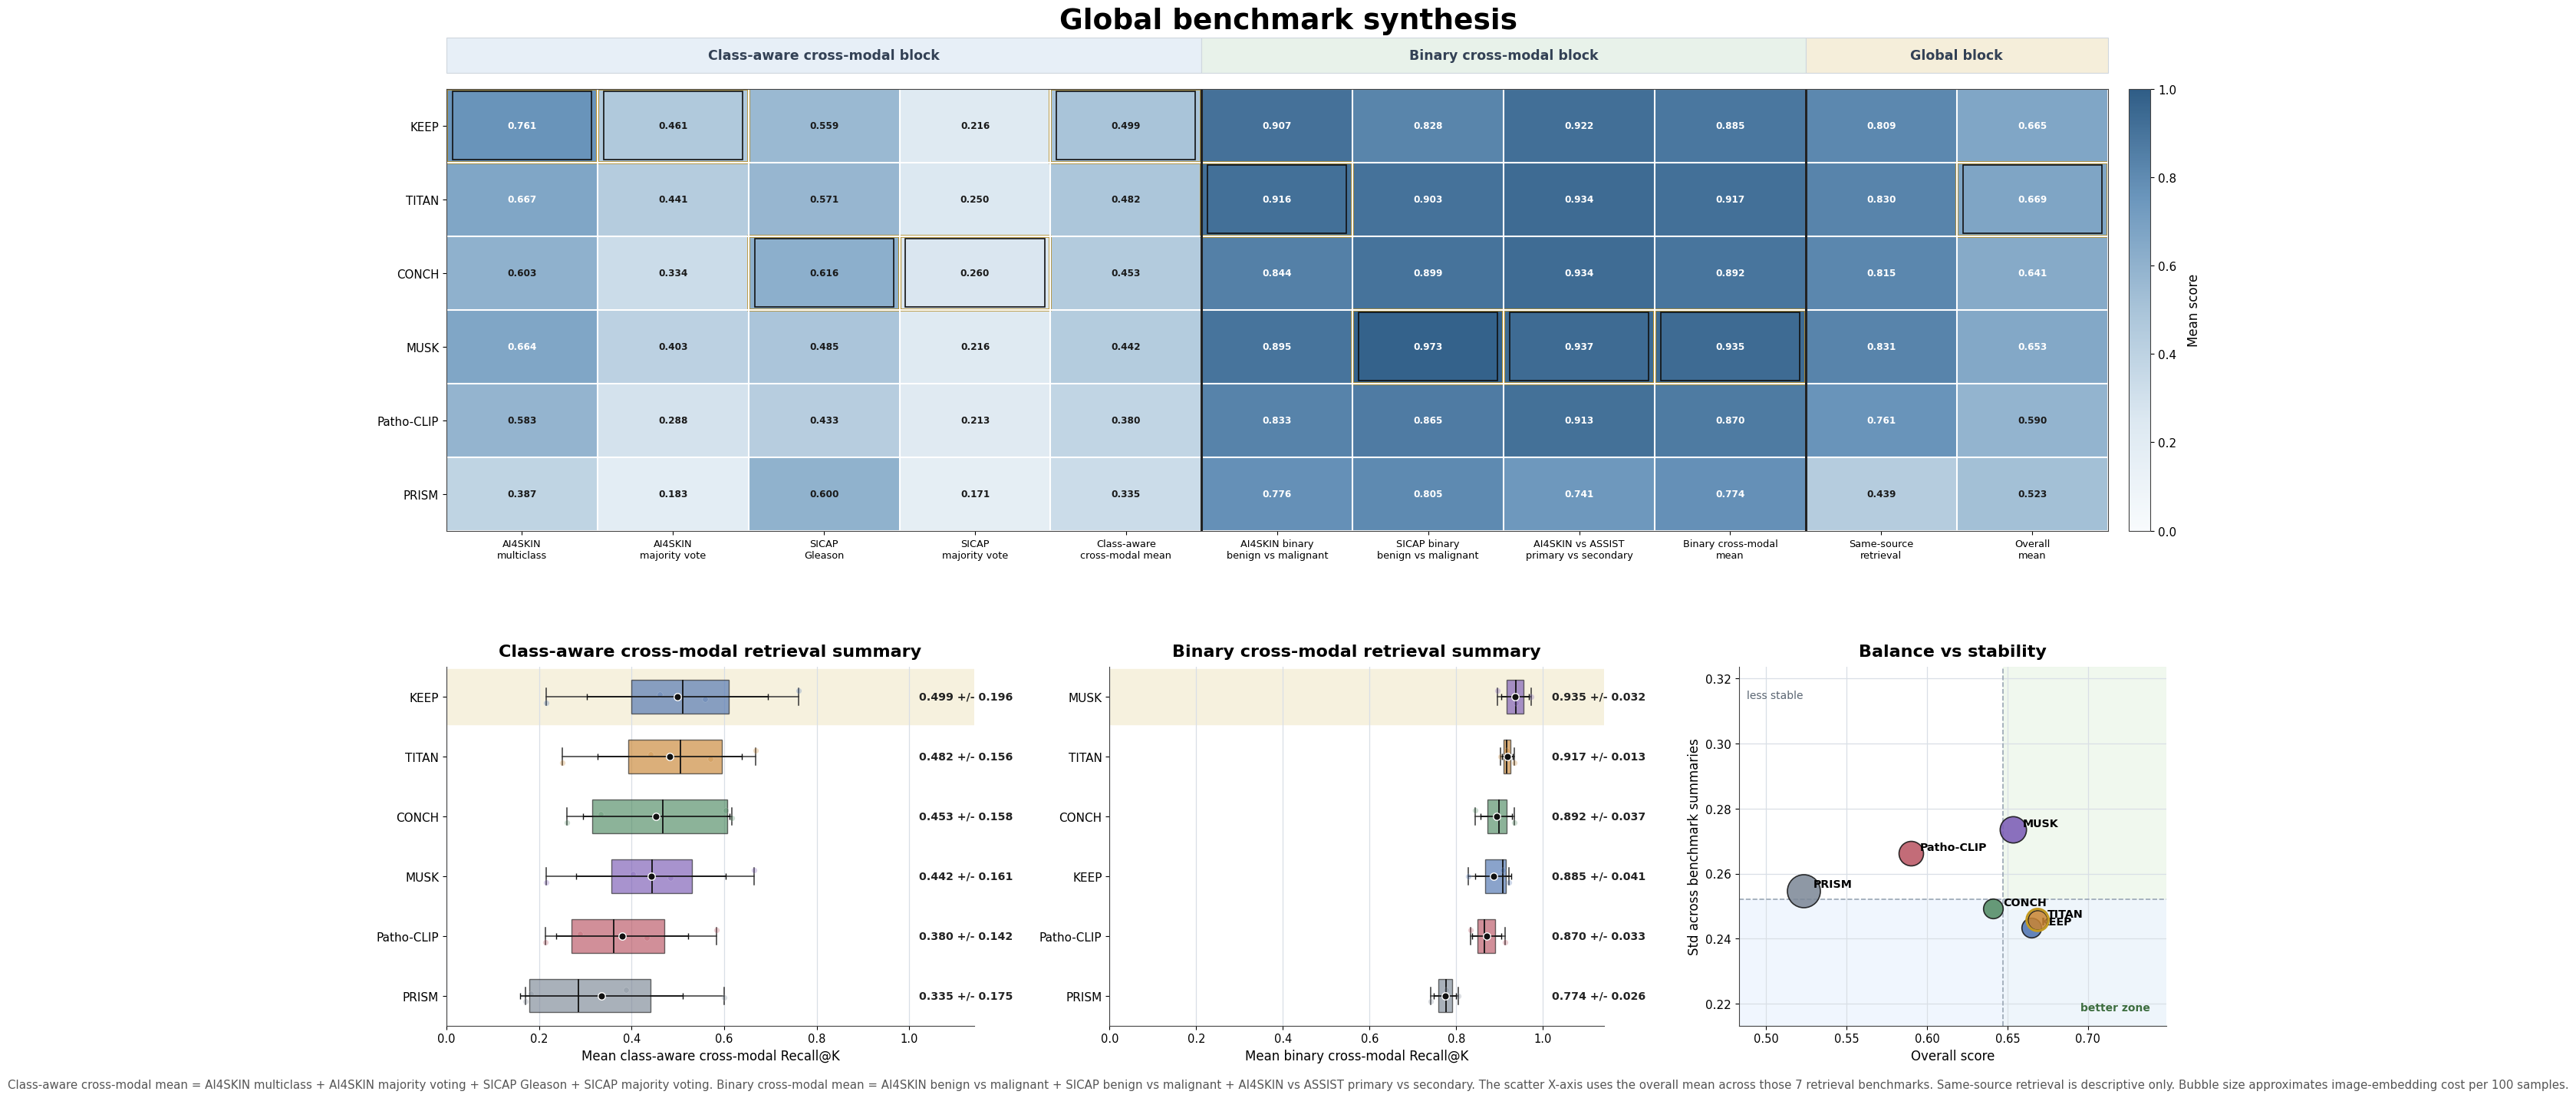

### Quick reading
- **Cross-modal I->R**: best overall profile = **MUSK** with **0.788 +/- 0.183**.
- **Cross-modal R->I**: best overall profile = **TITAN** with **0.823 +/- 0.134**.
- **Intramodal R->R**: best overall profile = **KEEP** with **0.849 +/- 0.107**.
- **Intramodal I->I**: best overall profile = **TITAN** with **0.818 +/- 0.094**.
- **AI4SKIN majority voting**: strongest mean returned-class profile = **KEEP** with **0.461 +/- 0.164**.
- **SICAP Gleason majority voting**: strongest mean returned-class profile = **CONCH** with **0.260 +/- 0.116**.
- **Most complete global profile**: **TITAN** with overall mean **0.669**, overall std **0.246** and completeness **0.423**.
- `Same-source retrieval` remains descriptive only: it indicates how often the retrieval stays inside the same source cohort in AI4SKIN vs ASSIST and should not be interpreted as diagnostic performance.

In [12]:
# Dashboard 1: retrieval directions
fig = plt.figure(figsize=(21.5, 13.3))
gs = fig.add_gridspec(2, 2, hspace=0.34, wspace=0.28)
ax_1 = fig.add_subplot(gs[0, 0])
ax_2 = fig.add_subplot(gs[0, 1])
ax_3 = fig.add_subplot(gs[1, 0])
ax_4 = fig.add_subplot(gs[1, 1])

plot_direction_panel(ax_1, i2r_summary, "Cross-modal I->R", "AI4SKIN multiclass; AI4SKIN and SICAP benign vs malignant; SICAP Gleason; AI4SKIN vs ASSIST primary vs secondary.")
plot_direction_panel(ax_2, r2i_summary, "Cross-modal R->I", "Same benchmarks as the I->R panel, now viewed from report-to-image retrieval.")
plot_direction_panel(ax_3, rr_summary, "Intramodal R->R", "AI4SKIN intramodal plus SICAP binary and SICAP Gleason report-to-report retrieval.")
plot_direction_panel(ax_4, ii_summary, "Intramodal I->I", "AI4SKIN intramodal plus SICAP binary and SICAP Gleason image-to-image retrieval.")

fig.suptitle("Retrieval directions across benchmarks", fontsize=25, fontweight="bold", y=0.99)
fig.text(
    0.5,
    0.03,
    "Cross-modal panels aggregate AI4SKIN multiclass, AI4SKIN benign vs malignant, SICAP benign vs malignant, SICAP Gleason and AI4SKIN vs ASSIST primary vs secondary. Intramodal panels aggregate AI4SKIN intramodal plus SICAP binary and SICAP Gleason. Black whiskers show std across benchmarks.",
    ha="center",
    fontsize=10.8,
    color="#555555",
)
fig.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.09)
maybe_save(fig, "dashboard_01_retrieval_directions.png")
plt.show()

# Dashboard 2: majority voting summaries
fig = plt.figure(figsize=(23.4, 13.8))
gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[1.0, 1.0, 0.05],
    height_ratios=[1.0, 0.76],
    hspace=0.48,
    wspace=0.29,
)
ax_ai_heat = fig.add_subplot(gs[0, 0])
ax_sicap_heat = fig.add_subplot(gs[0, 1])
ax_cbar = fig.add_subplot(gs[0, 2])
ax_ai_summary = fig.add_subplot(gs[1, 0])
ax_sicap_summary = fig.add_subplot(gs[1, 1])

im_ai = draw_class_heatmap(
    ax_ai_heat,
    ai4skin_majority_df,
    "AI4SKIN majority voting",
    "Rows = true class. Values = diagonal returned-class percentage averaged over K={1,3,5,10} and both directions.",
)
im_si = draw_class_heatmap(
    ax_sicap_heat,
    sicap_majority_df,
    "SICAP Gleason majority voting",
    "Computed from the stored SICAP text/image embeddings with the same top-K majority-vote rule.",
)

cbar = fig.colorbar(im_ai, cax=ax_cbar)
cbar.set_label("Mean returned-class score", rotation=90, labelpad=10)

plot_rank_summary(
    ax_ai_summary,
    ai4skin_majority_summary,
    "AI4SKIN class-profile summary",
    "Mean returned-class percentage across AI4SKIN classes",
)
plot_rank_summary(
    ax_sicap_summary,
    sicap_majority_summary,
    "SICAP Gleason class-profile summary",
    "Mean returned-Gleason percentage across SICAP classes",
)

fig.suptitle("Majority-vote class summaries", fontsize=25, fontweight="bold", y=0.98)
fig.text(
    0.5,
    0.02,
    "The last row in each heatmap is the mean across classes. The lower panels condense those tables into model-level profiles with the class spread still visible. SICAP uses the same top-K majority-vote rule as AI4SKIN, but applied to Gleason prediction from the stored final embeddings.",
    ha="center",
    fontsize=10.7,
    color="#555555",
)
fig.subplots_adjust(left=0.065, right=0.955, top=0.885, bottom=0.09)
maybe_save(fig, "dashboard_02_majority_vote_summaries.png")
plt.show()

# Dashboard 3: global synthesis
synthesis_cols = [
    "AI4SKIN multiclass",
    "AI4SKIN majority",
    "SICAP Gleason",
    "SICAP majority",
    "Class-aware mean",
    "AI4SKIN binary",
    "SICAP binary",
    "AI4SKIN vs ASSIST",
    "Binary mean",
    "Same-source retrieval",
    "Overall mean",
]
synthesis_labels = [
    "AI4SKIN\nmulticlass",
    "AI4SKIN\nmajority vote",
    "SICAP\nGleason",
    "SICAP\nmajority vote",
    "Class-aware\ncross-modal mean",
    "AI4SKIN binary\nbenign vs malignant",
    "SICAP binary\nbenign vs malignant",
    "AI4SKIN vs ASSIST\nprimary vs secondary",
    "Binary cross-modal\nmean",
    "Same-source\nretrieval",
    "Overall\nmean",
]

top_df = summary_df.set_index("model").reindex(models)
top_matrix = top_df[synthesis_cols].to_numpy(dtype=float)

fig = plt.figure(figsize=(23.6, 14.8))
gs = fig.add_gridspec(
    2,
    3,
    height_ratios=[1.38, 1.12],
    width_ratios=[1.26, 1.18, 1.02],
    hspace=0.34,
    wspace=0.28,
)
ax_top = fig.add_subplot(gs[0, :])
ax_fine = fig.add_subplot(gs[1, 0])
ax_binary = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])

im = ax_top.imshow(np.ma.masked_invalid(top_matrix), aspect="auto", cmap=thesis_cmap(), vmin=0.0, vmax=1.0)
ax_top.set_xticks(np.arange(len(synthesis_cols)))
ax_top.set_xticklabels(synthesis_labels)
ax_top.set_yticks(np.arange(len(models)))
ax_top.set_yticklabels(models)
ax_top.tick_params(axis="x", labelsize=9.3, pad=4)
ax_top.tick_params(axis="y", labelsize=10.8)
ax_top.set_xticks(np.arange(-0.5, len(synthesis_cols), 1), minor=True)
ax_top.set_yticks(np.arange(-0.5, len(models), 1), minor=True)
ax_top.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax_top.tick_params(which="minor", bottom=False, left=False)
for xpos in [4.5, 8.5]:
    ax_top.axvline(x=xpos, color="#222222", linewidth=2.2)
draw_block_headers(
    ax_top,
    [
        ("Class-aware cross-modal block", 5, "#E7EFF7"),
        ("Binary cross-modal block", 4, "#E8F2EA"),
        ("Global block", 2, "#F5EEDA"),
    ],
)
add_best_boxes(ax_top, top_matrix, mode="max", skip_cols=[9])
annotate_heatmap(ax_top, top_matrix)

cbar = fig.colorbar(im, ax=ax_top, fraction=0.022, pad=0.012)
cbar.set_label("Mean score", rotation=90, labelpad=10)

plot_rank_summary(
    ax_fine,
    fine_summary,
    "Class-aware cross-modal retrieval summary",
    "Mean class-aware cross-modal Recall@K",
)
plot_rank_summary(
    ax_binary,
    binary_summary,
    "Binary cross-modal retrieval summary",
    "Mean binary cross-modal Recall@K",
)

scatter_df = top_df.reset_index().rename(columns={"index": "model"})
x_mid = float(scatter_df["Overall mean"].median())
y_mid = float(scatter_df["Overall std"].median())
x_min = max(0.0, float(scatter_df["Overall mean"].min()) - 0.04)
x_max = min(1.0, float(scatter_df["Overall mean"].max()) + 0.08)
y_min = max(0.0, float(scatter_df["Overall std"].min()) - 0.03)
y_max = float(scatter_df["Overall std"].max()) + 0.05

ax_scatter.axvspan(x_mid, x_max, color="#EEF7EC", alpha=0.85, zorder=0)
ax_scatter.axhspan(y_min, y_mid, color="#EEF5FE", alpha=0.85, zorder=0)
ax_scatter.axvline(x_mid, color="#99A6B4", linestyle="--", linewidth=1.2)
ax_scatter.axhline(y_mid, color="#99A6B4", linestyle="--", linewidth=1.2)

bubble_sizes = scale_bubble_sizes(IMAGE_EMBEDDING_SEC_PER_100, scatter_df["model"].tolist())

for idx, (_, row) in enumerate(scatter_df.iterrows()):
    is_complete = row["model"] == most_complete_model
    ax_scatter.scatter(
        row["Overall mean"],
        row["Overall std"],
        s=float(bubble_sizes[idx]),
        color=MODEL_COLORS[row["model"]],
        alpha=0.86,
        edgecolor="#111111",
        linewidth=1.2,
        zorder=3,
    )
    if is_complete:
        ax_scatter.scatter(
            row["Overall mean"],
            row["Overall std"],
            s=float(bubble_sizes[idx]) * 1.24,
            facecolors="none",
            edgecolors="#C39A22",
            linewidth=2.3,
            zorder=4,
        )
    ax_scatter.text(
        row["Overall mean"] + 0.006,
        row["Overall std"] + 0.001,
        row["model"],
        fontsize=10.3,
        fontweight="bold",
    )

ax_scatter.set_title("Balance vs stability", pad=10, fontweight="bold")
ax_scatter.set_xlabel("Overall score")
ax_scatter.set_ylabel("Std across benchmark summaries")
ax_scatter.set_xlim(x_min, x_max)
ax_scatter.set_ylim(y_min, y_max)
ax_scatter.grid(True, color="#D9DFE6", linewidth=0.9)
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)
ax_scatter.text(x_max - 0.01, y_min + 0.004, "better zone", ha="right", va="bottom", fontsize=10, color="#3D6D3F", fontweight="bold")
ax_scatter.text(x_min + 0.005, y_max - 0.007, "less stable", ha="left", va="top", fontsize=10, color="#5B6673")

fig.suptitle("Global benchmark synthesis", fontsize=27, fontweight="bold", y=0.972)
fig.text(
    0.5,
    0.02,
    "Class-aware cross-modal mean = AI4SKIN multiclass + AI4SKIN majority voting + SICAP Gleason + SICAP majority voting. Binary cross-modal mean = AI4SKIN benign vs malignant + SICAP benign vs malignant + AI4SKIN vs ASSIST primary vs secondary. The scatter X-axis uses the overall mean across those 7 retrieval benchmarks. Same-source retrieval is descriptive only. Bubble size approximates image-embedding cost per 100 samples.",
    ha="center",
    fontsize=10.8,
    color="#555555",
)
fig.subplots_adjust(left=0.035, right=0.985, top=0.90, bottom=0.075)
maybe_save(fig, "dashboard_03_global_synthesis.png")
plt.show()

# Quick reading for the written memory.
direction_winners = {
    "Cross-modal I->R": i2r_summary.sort_values("mean", ascending=False).iloc[0],
    "Cross-modal R->I": r2i_summary.sort_values("mean", ascending=False).iloc[0],
    "Intramodal R->R": rr_summary.sort_values("mean", ascending=False).iloc[0],
    "Intramodal I->I": ii_summary.sort_values("mean", ascending=False).iloc[0],
}
ai4skin_winner = ai4skin_majority_summary.sort_values("mean", ascending=False).iloc[0]
sicap_winner = sicap_majority_summary.sort_values("mean", ascending=False).iloc[0]
complete_row = summary_df.sort_values("Completeness", ascending=False).iloc[0]

lines = []
lines.append("### Quick reading")
for title, row in direction_winners.items():
    lines.append(f"- **{title}**: best overall profile = **{row['model']}** with **{row['mean']:.3f} +/- {row['std']:.3f}**.")
lines.append(f"- **AI4SKIN majority voting**: strongest mean returned-class profile = **{ai4skin_winner['model']}** with **{ai4skin_winner['mean']:.3f} +/- {ai4skin_winner['std']:.3f}**.")
lines.append(f"- **SICAP Gleason majority voting**: strongest mean returned-class profile = **{sicap_winner['model']}** with **{sicap_winner['mean']:.3f} +/- {sicap_winner['std']:.3f}**.")
lines.append(f"- **Most complete global profile**: **{complete_row['model']}** with overall mean **{complete_row['Overall mean']:.3f}**, overall std **{complete_row['Overall std']:.3f}** and completeness **{complete_row['Completeness']:.3f}**.")
lines.append("- `Same-source retrieval` remains descriptive only: it indicates how often the retrieval stays inside the same source cohort in AI4SKIN vs ASSIST and should not be interpreted as diagnostic performance.")

display(Markdown("\n".join(lines)))